In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from Tracer.fluctuator import gust_Langevin, gust_simple
from Tracer import WindField

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=10.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=10.0, z0=0.03, z_ref=10.0


In [3]:
file = '../RANS/nc files/LES-90m-8ms.nc' # z0=0.03, U_ref=8, z_ref=90
ds = xr.open_dataset(file)

In [4]:
point_i = {'x': 0, 'y': 0, 'z': 2}  # corresponding indices in LES dataset (assuming z[4] ~ 22.5m)
data = ds.isel(**point_i)
t, z_i = data.t.values, data.z.values

In [5]:
u_ref = 8
sim_field = WindField(profile="log", direction=0, U_ref=u_ref, z_ref=90, z0=0.03)
rans_wind = WindField(profile='rans', ds = '../RANS/nc files/flowdata_2m_cartesian.nc', U_ref=8)
wind, tke, epsilon = sim_field.get_profile_at(z=z_i) # only need z for pure log
wind_rans, tke_rans, epsilon_rans = rans_wind.get_profile_at(x=0, y=0, z=z_i) # get RANS wind at specific location

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8, z0=0.03, z_ref=90


In [6]:
rans_wind

WindField(profile=rans) 
Size: 370MB
Dimensions:  (x: 257, y: 257, z: 100)
Coordinates:
  * x        (x) float64 2kB -256.0 -254.0 -252.0 -250.0 ... 252.0 254.0 256.0
  * y        (y) float64 2kB -256.0 -254.0 -252.0 -250.0 ... 252.0 254.0 256.0
  * z        (z) float64 800B 0.1 0.1072 0.115 0.1233 ... 86.97 93.26 100.0
Data variables:
    U        (x, y, z) float64 53MB 1.272 1.328 1.387 ... 7.968 8.038 8.109
    V        (x, y, z) float64 53MB -4.847e-06 -5.055e-06 ... 8.629e-07
    W        (x, y, z) float64 53MB -2.779e-09 -3.071e-09 ... -7.305e-05
    P        (x, y, z) float64 53MB ...
    muT      (x, y, z) float64 53MB ...
    tke      (x, y, z) float64 53MB 0.121 0.1211 0.1213 ... 0.1191 0.1192 0.1192
    epsilon  (x, y, z) float64 53MB 0.02331 0.0222 ... 2.789e-05 2.604e-05
Attributes:
    PyWakeEllipSys_version:  6.1
    xWFc:                    0.0
    yWFc:                    0.0
    grid_wd:                 270.0
    resolution:              2.0
    scaling:              

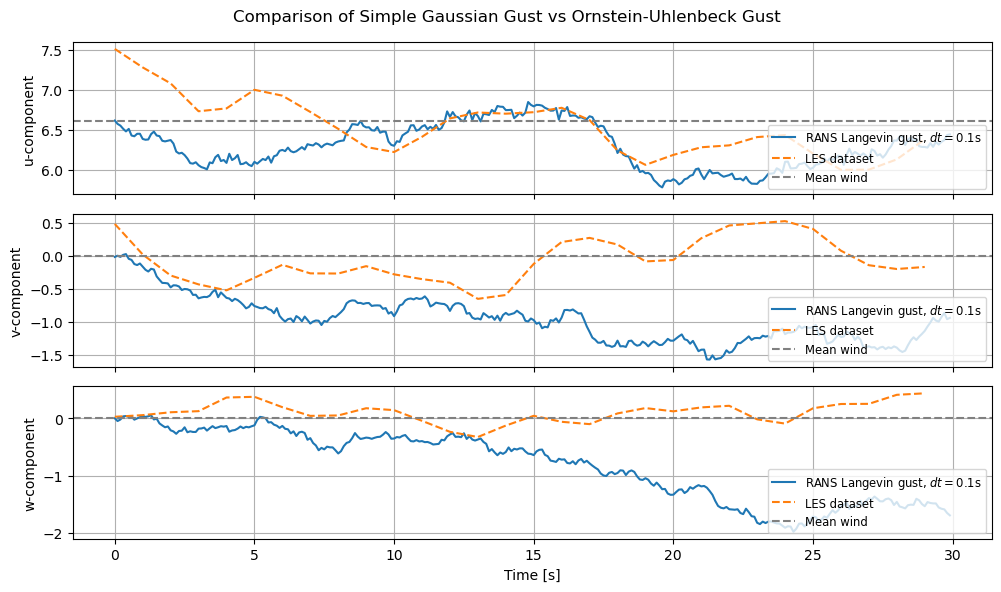

In [ ]:
rng = np.random.default_rng(42)

mt = 30  # max time for simulation (s)
dt = 0.1
n_steps = int(mt/dt)
time = np.arange(0, mt, dt)

# storage arrays
simple_hist = np.zeros((n_steps, 3))
lang_hist = np.zeros((n_steps, 3))
rans_lang_hist = np.zeros((n_steps, 3))

simple_state = np.zeros(3)
gust_state_lang = np.zeros(3)
gust_state_rans_lang = np.zeros(3)


for i in range(n_steps):
    simple_hist[i] = gust_simple(wind, tke, rng)
    lang_wind, gust_state_lang = gust_Langevin(wind, tke, epsilon, gust_state_lang, rng, dt, C0=2.1, cf=1)
    lang_hist[i] = lang_wind

    rans_lang_wind, gust_state_rans_lang = gust_Langevin(wind_rans, tke_rans, epsilon_rans, gust_state_rans_lang, rng, dt, C0=2.1, cf=1)
    rans_lang_hist[i] = rans_lang_wind


# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

labels = ['u-component', 'v-component', 'w-component']

for j in range(3):
    # axs[j].plot(time, simple_hist[:, j], label=r'Simple Gaussian gust, $dt=0.1$s')
    # axs[j].plot(time, lang_hist[:, j], label=r'OU Langevin gust, $dt=0.1$s')
    axs[j].plot(time, rans_lang_hist[:, j], label=r'RANS Langevin gust, $dt=0.1$s')
    axs[j].plot(ds.t[:mt], ds.isel(**point_i)[labels[j][0]].values[:mt], label='LES dataset', linestyle='--')
    axs[j].axhline(wind[j], linestyle='--', color='gray', label='Mean wind')
    axs[j].set_ylabel(labels[j])
    axs[j].legend(loc='lower right', fontsize='small')
    axs[j].grid(True)

axs[2].set_xlabel('Time [s]')
plt.suptitle('Comparison of Simple Gaussian Gust vs Ornstein-Uhlenbeck Gust')
plt.tight_layout()
plt.show()


In [8]:
# sanity check with means:

# OU
print("="*5, ' OU ', "="*5)
print(u_ref - np.mean(ou_hist[:, 0]), np.mean(ou_hist[:, 1]), np.mean(ou_hist[:, 2]))

# Langevin
print("="*5, ' Langevin ', "="*5)
print(u_ref - np.mean(lang_hist[:, 0]), np.mean(lang_hist[:, 1]), np.mean(lang_hist[:, 2]))

# Les
print("="*5, ' LES ', "="*5)
print(u_ref - np.mean(ds.isel(**point_i)['u'].values), np.mean(ds.isel(**point_i)['v'].values), np.mean(ds.isel(**point_i)['w'].values))

=====  OU  =====


NameError: name 'ou_hist' is not defined